# CRM Reactivation Methodology
## Goal

The objective is to identify the customers with the highest probability of being reactivated after a long inactivity period.

In business terms, the company wants to answer this question:

> Among the customers who have already stopped buying for at least 2 years, which ones are the best targets for a reactivation campaign?

In [17]:
import numpy as np
import pandas as pd

In [ ]:
client_df = pd.read_csv("./TOOL_CLIENT.csv")
sales_df = pd.read_csv("./TOOL_SALES.csv")

C:\Users\39346\AppData\Local\Temp\ipykernel_16868\2964368269.py:2: DtypeWarning: Columns (0: CANCELLED) have mixed types. Specify dtype option on import or set low_memory=False.
  sales_df = pd.read_csv("../TOOL_SALES.csv")


Visualize distance between transactions

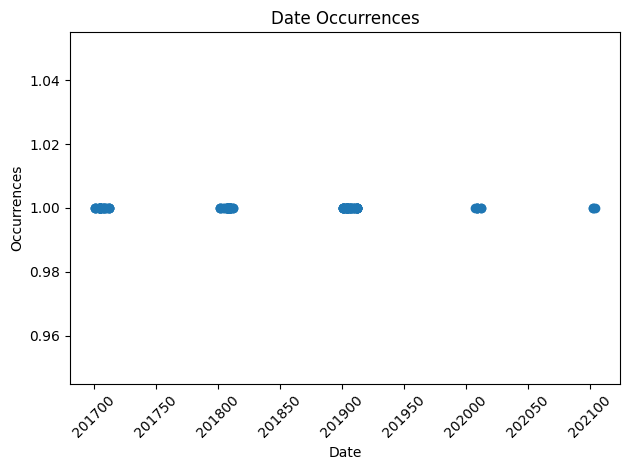

         YYYYMM  ITEM_ID  FLG_TOOL SALES_CHANNEL     NET UNIT FAMILY_CODE  \
0        201701       54         0             B   24.78    P     XBAM2HA   
30986    201701      527         0             B   31.19    P     XBAM2IA   
34259    201701    13685         0             B   86.51    P     XBAM2IA   
57602    201702    14132         0             B   98.40    P     XBAC2AD   
155081   201704      526         0             B   28.68    P     XBAM2IA   
...         ...      ...       ...           ...     ...  ...         ...   
1663883  202012     7900         0             B    6.63    P     XAEN2AE   
1663913  202012     7897         0             B   29.98    P     XAEN2AE   
1698354  202102      529         0             B   57.67    P     XBAL2AA   
1723040  202102      527         0             B   47.86    P     XBAL2AA   
1792298  202104    13676         0             B  200.58    P     XBAL2AA   

          GROUP_CODE  CLIENT_ID CANCELLED  
0        XBAM2HA0201      15674

In [19]:
import matplotlib.pyplot as plt

rows = sales_df[sales_df['CLIENT_ID'] == 15674]    # Replace 15674 with the desired CLIENT_ID

plt.scatter(rows['YYYYMM'],[1]*len(rows))
plt.xlabel('Date')
plt.ylabel('Occurrences')
plt.title('Date Occurrences')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(rows)

#  Dealing with datatypes

In [20]:
print(client_df.dtypes)
print(sales_df.dtypes)

CLIENT_ID               int64
CLIENT_CREATE DATE        str
REGION                    str
TRADE SECTOR            int64
N_EMPLOYEES             int64
ECONOMIC_POT          float64
ECO_POT_CLASS             str
RISK_CAT                  str
dtype: object
YYYYMM             int64
ITEM_ID            int64
FLG_TOOL           int64
SALES_CHANNEL        str
NET              float64
UNIT                 str
FAMILY_CODE          str
GROUP_CODE           str
CLIENT_ID          int64
CANCELLED            str
dtype: object


# Data cleaning
and data types adjustments

## in CLIENT_TOOL:

CLIENT_ID               int64  ->  ok

CLIENT_CREATE DATE     object  ->  datetime64[ns]

REGION                 object  ->  string

TRADE SECTOR            int64  ->  ok

N_EMPLOYEES             int64  ->  ok

ECONOMIC_POT          float64  ->  ok

ECO_POT_CLASS          object  ->  string
 
RISK_CAT               object  -> string


In [21]:
client_df["CLIENT_CREATE DATE"] = pd.to_datetime(client_df["CLIENT_CREATE DATE"])
client_df["REGION"] = client_df["REGION"].astype("string")
#cambia raggruppando le regioni in macroaree
client_df["REGION"] = client_df["REGION"].fillna("unknown")
client_df["REGION"] = client_df["REGION"].astype("string")
client_df["ECO_POT_CLASS"] = client_df["ECO_POT_CLASS"].astype("string")
client_df["RISK_CAT"] = client_df["RISK_CAT"].astype("string")
# display(client_df.dtypes)
# display(client_df)


## In Sales:

YYYYMM             int64   ->  datetime64[ns]

ITEM_ID            int64   ->  ok

FLG_TOOL           int64   ->  ok

SALES_CHANNEL     object   ->  string

NET              float64   ->  ok

UNIT              object   ->  string

FAMILY_CODE       object   ->  string

GROUP_CODE        object   ->  string

CLIENT_ID          int64   ->  ok

CANCELLED         object   ->  string

In [22]:

sales_df["UNIT"] = sales_df["UNIT"].astype("string")
sales_df["FAMILY_CODE"] = sales_df["FAMILY_CODE"].astype("string")

sales_df["YYYYMM"] = pd.to_datetime(sales_df["YYYYMM"], format="%Y%m")
sales_df["SALES_CHANNEL"] = sales_df["SALES_CHANNEL"].astype("string")

sales_df['CANCELLED'] = (sales_df['CANCELLED'] == 'X').astype(int)
sales_df.loc[sales_df['NET'] < 0, 'NNET'] = sales_df['NET']
#Now NNET contains the negative values of NET, while NET contains the non-negative values. This way we can keep track of both sales and returns in separate columns.
sales_df['NET'] = sales_df['NET'].where(sales_df['NET'] >= 0, np.nan) 
sales_df['NNET'] = sales_df['NNET'].where(sales_df['NNET'] <= 0, np.nan)  #NeW COLUMN!

## Inspecting transactions

standalone transactions are not usefull.
Transactions with negative values (not standalone) could provide usefull informations about a client.

In [23]:
df_unique = sales_df[~sales_df["CLIENT_ID"].duplicated(keep=False)]
# df_unique = client_df[~client_df["column_name"].duplicated(keep=False)]
print(f"\"standalone\" transactions: {len(df_unique)}, over a total of: {len(sales_df)} that is {len(df_unique)/len(sales_df)*100:.2f}%")
print(f"Transactions with negative values: {len(sales_df[sales_df['NNET'] < 0])}")

"standalone" transactions: 13150, over a total of: 2050449 that is 0.64%
Transactions with negative values: 2298


Removing standalone transactions

In [24]:
print(f"Dimension of sales before filtering: {len(sales_df) }")
sales_df = sales_df[~sales_df['CLIENT_ID'].isin(df_unique['CLIENT_ID'])]
print(f"Dimension of sales after filtering: {len(sales_df) }")

Dimension of sales before filtering: 2050449
Dimension of sales after filtering: 2037299


Removing client that made more than one transaction, but on a single day, and then disappeared. 

In [25]:
daily_counts = (
    sales_df.groupby(['CLIENT_ID', 'YYYYMM'])
    .size()
    .reset_index(name='n_days_purchase')
)
daily_counts

days_per_client = (
    sales_df.groupby('CLIENT_ID')['YYYYMM']
    .nunique()
    .reset_index(name='n_days')
)

multi_same_day = (
    daily_counts.groupby('CLIENT_ID')['n_days_purchase']
    .max()
    .reset_index(name='max_same_day_purchases')
)
# print(days_per_client)
# print(multi_same_day)
clients_to_remove = (
    days_per_client.merge(multi_same_day, on='CLIENT_ID')
)


clients_to_remove = clients_to_remove[
    (clients_to_remove['n_days'] == 1) &
    (clients_to_remove['max_same_day_purchases'] > 1)
]['CLIENT_ID']

print(len(sales_df))
sales_df = sales_df[~sales_df['CLIENT_ID'].isin(clients_to_remove)]
print(len(sales_df))
client_df = client_df[~client_df['CLIENT_ID'].isin(clients_to_remove)]

2037299
1931363


# Dates

In [26]:
feature_start = pd.Timestamp("2017-01-01")
feature_end = pd.Timestamp("2017-12-31")

cutoff_date = pd.Timestamp("2019-12-31")

min_registration_date = pd.Timestamp("2016-12-31")

outcome_start = pd.Timestamp("2020-01-01")
outcome_end = pd.Timestamp("2021-12-31")

# Inspecting clients


 

In [27]:
clients = sales_df['CLIENT_ID'].unique()
total_clients = len(clients)
print(f"Total clients: {total_clients}")

Total clients: 59214


Removing clients

In [28]:
# These clients are not part of the inactive pool
clients_active_2017_2018 = set(
    sales_df.loc[ sales_df["YYYYMM"].between(feature_start, feature_end), "CLIENT_ID" ].unique()
)

print("Clients active in 2017-2018:", len(clients_active_2017_2018))

final_set = set(clients) - clients_active_2017_2018
print("Valid clients: ", len(final_set))
print(f"{len(final_set)} out of {total_clients}, which is {len(final_set)/total_clients*100:.2f}%")

# 5) activ  clients in 2019-2020
clients_activ_2019_2020 = set(
    sales_df.loc[
        sales_df["YYYYMM"].between(outcome_start, outcome_end),
        "CLIENT_ID"
    ].unique()
)

#we have to subtract clients which are not in the final set, as they are not part of the inactive pool 
clients_reactivated_2019_2020 = final_set.intersection(clients_activ_2019_2020)

print(f"Clients reactivated in 2019-2020: {len(clients_reactivated_2019_2020)} which is {len(clients_reactivated_2019_2020)/total_clients*100:.2f}% of the total clients, and {len(clients_reactivated_2019_2020)/len(final_set)*100:.2f}% of the inactive clients.")


Clients active in 2017-2018: 38488
Valid clients:  20726
20726 out of 59214, which is 35.00%
Clients reactivated in 2019-2020: 16247 which is 27.44% of the total clients, and 78.39% of the inactive clients.


Creating new dataframes to use from now on with only valid clients.

In [29]:
new_client_df = client_df[client_df["CLIENT_ID"].isin(final_set)]
new_sales_df = sales_df[sales_df["CLIENT_ID"].isin(final_set)]
model_df = new_client_df

creating the target and  getting the reactivation rate 

In [30]:
new_client_df["target"] = new_client_df["CLIENT_ID"].isin(clients_reactivated_2019_2020).astype(int)

print(f"{(new_client_df['target'] == 1).sum()/len(new_client_df)*100:.2f}% of the clients reactivated in 2019-2020")

78.39% of the clients reactivated in 2019-2020


# Features engineering


In [31]:

model_df["client_age_months"] = (
    (cutoff_date.year - model_df["CLIENT_CREATE DATE"].dt.year) * 12
    + (cutoff_date.month - model_df["CLIENT_CREATE DATE"].dt.month)
)

Features that can be derived from transactions:

In [32]:
#Features that can be derived from transactions:
total_per_cust      = new_sales_df.groupby("CLIENT_ID")["NET"].sum()
tnsx_per_cust       = new_sales_df.groupby("CLIENT_ID")["NET"].count()
mean_spent_per_cust = new_sales_df.groupby("CLIENT_ID")["NET"].mean()
model_df["total_amount"]        = model_df["CLIENT_ID"].map(total_per_cust)
model_df["tsnx_p_cust"]         = model_df["CLIENT_ID"].map(tnsx_per_cust)
model_df["mean_spent_per_cust"] = model_df["CLIENT_ID"].map(mean_spent_per_cust)

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

In [34]:
client_df["target"] = client_df["CLIENT_ID"].isin(clients_reactivated_2019_2020).astype(int)

X = client_df.copy()
X.drop(columns=["target","CLIENT_ID"], inplace=True)
y = client_df["target"].copy()


In [35]:
# columns with string/object data
categorical_features = client_df.select_dtypes(include=[ 'string']).columns.tolist()

# columns with numeric data: int64 and float64
numeric_features = client_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_features.remove("CLIENT_ID")  
numeric_features.remove("target")  


In [36]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

In [37]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

# print("X_train:", X_train.shape)
# print("X_test:", X_test.shape)
# print("Train target mean:", y_train.mean())
# print("Test target mean:", y_test.mean())

clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [38]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

AUC: 0.6506920847623053

Classification report:
              precision    recall  f1-score   support

           0       0.79      0.99      0.88     11224
           1       0.65      0.07      0.13      3249

    accuracy                           0.78     14473
   macro avg       0.72      0.53      0.50     14473
weighted avg       0.76      0.78      0.71     14473

Confusion matrix:
[[11100   124]
 [ 3020   229]]


In [39]:
# Get transformed feature names from the fitted preprocessor
feature_names = clf.named_steps["preprocessor"].get_feature_names_out()

# Get logistic regression coefficients
coefs = clf.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "abs_coefficient": np.abs(coefs),
    "odds_ratio": np.exp(coefs)
}).sort_values("abs_coefficient", ascending=False)

display(coef_df.head(20))

,feature,coefficient,abs_coefficient,odds_ratio
134,cat__RISK_CAT_4d,-1.767889,1.767889,0.170693
135,cat__RISK_CAT_5a,1.454958,1.454958,4.284304
136,cat__RISK_CAT_5b,1.297057,1.297057,3.658514
137,cat__RISK_CAT_5c,1.134937,1.134937,3.110977
139,cat__RISK_CAT_T8,-0.983552,0.983552,0.373980
122,cat__RISK_CAT_1d,-0.898311,0.898311,0.407257
130,cat__RISK_CAT_3d,-0.811215,0.811215,0.444318
126,cat__RISK_CAT_2d,0.751117,0.751117,2.119366
138,cat__RISK_CAT_5d,-0.743166,0.743166,0.475606
9,cat__REGION_AN,-0.629197,0.629197,0.533020


# Boosted tree model

In [ ]:
from sklearn.ensemble import RandomForestClassifier


clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(max_depth=10, random_state=42))
])

clf.fit(X_train, y_train)

In [ ]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))